# 유형 B 상권 분석 — 도봉·은평·노원 시니어 생활밀착형 페르소나

**분석 목적**: B유형 상권이 지금 어떤 상태이고, 어떤 문제가 있으며, 상권 유형별로 어떤 전략을 써야 매출을 끌어올릴 수 있는가를 데이터로 제시한다.

> ⚠️ **데이터 한계**: 추론 기반 추정매출 + 길단위인구 데이터 사용. 현금 사용 비중이 높고 스마트폰 기반 데이터 수집이 어려운 디지털 소외계층 데이터 누락 우려 있음.

**분석 흐름**
1. 현황 — 규모·시간대·고객 프로파일
2. 상권 세분화 — K-Means 4개 유형 도출
3. 유형별 문제 진단 + 맞춤 전략 + **예상 매출 지표**
4. 지도 시각화 (유형별 색상)

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import folium
from folium.plugins import MiniMap
from pyproj import Transformer
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

OKR_COLORS = ['#2166ac', '#d6604d', '#1a9850', '#f4a582']  # 클러스터 색상

In [26]:
# ── 1. 영역 데이터: 도봉·은평·노원 상권 목록 + 좌표 변환
df_area = pd.read_csv(
    '../data/extracted/서울시_상권분석서비스(추정매출+영역)/서울시 상권분석서비스(영역-상권).csv',
    encoding='euc-kr'
)
TARGET_GU = ['도봉구', '은평구', '노원구']
df_area_b = df_area[df_area['자치구_코드_명'].isin(TARGET_GU)].copy()
target_codes = set(df_area_b['상권_코드'])

# TM(EPSG:5174) → WGS84(EPSG:4326)
transformer = Transformer.from_crs('EPSG:5174', 'EPSG:4326', always_xy=True)
lons, lats = transformer.transform(
    df_area_b['엑스좌표_값'].values,
    df_area_b['와이좌표_값'].values
)
df_area_b = df_area_b.copy()
df_area_b['lat'] = lats
df_area_b['lon'] = lons

print(f'대상 상권 수: {len(df_area_b)}개')
df_area_b[['상권_코드_명', '자치구_코드_명', 'lat', 'lon']].head(5)

대상 상권 수: 153개


,상권_코드_명,자치구_코드_명,lat,lon
372,쌍문역1번(쌍리단길),도봉구,37.651037,127.037253
373,도봉산입구,도봉구,37.687247,127.038562
374,쌍문2동우체국,도봉구,37.657641,127.037936
375,창2동주민센터,도봉구,37.644324,127.039923
376,방학초등학교,도봉구,37.665697,127.032783


In [27]:
# ── 2. 추정매출 2025년 4분기(20254) + 도봉·은평·노원 필터
df_sales_raw = pd.read_csv(
    '../data/extracted/서울시_상권분석서비스(추정매출+영역)/서울시_상권분석서비스(추정매출-상권)_2025년.csv',
    encoding='euc-kr'
)
df_sales_b = df_sales_raw[
    (df_sales_raw['기준_년분기_코드'] == 20254) &
    (df_sales_raw['상권_코드'].isin(target_codes))
].copy()

# ── 3. 길단위 인구 + 도봉·은평·노원 필터
df_pop_raw = pd.read_csv(
    '../data/extracted/서울시 상권분석서비스(길단위인구-상권)/서울시 상권분석서비스(길단위인구-상권).csv',
    encoding='euc-kr'
)
df_pop_b = df_pop_raw[df_pop_raw['상권_코드'].isin(target_codes)].copy()

print(f'추정매출: {len(df_sales_b)}행 (업종별) / {df_sales_b["상권_코드"].nunique()}개 상권')
print(f'길단위인구: {len(df_pop_b)}행 / 분기: {df_pop_b["기준_년분기_코드"].unique()[:5]}')
print(f'업종 종류: {df_sales_b["서비스_업종_코드_명"].nunique()}개')
df_sales_b[['상권_코드_명', '서비스_업종_코드_명', '당월_매출_금액', '당월_매출_건수']].head(5)

추정매출: 2063행 (업종별) / 142개 상권
길단위인구: 4284행 / 분기: [20254 20253 20252 20251 20244]
업종 종류: 61개


,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수
1867,불광먹자골목 골목형상점가,운동/경기용품,103346579,1161
1868,불광먹자골목 골목형상점가,의료기기,38225174,202
1869,불광먹자골목 골목형상점가,의약품,2211622167,140716
1870,불광먹자골목 골목형상점가,시계및귀금속,31740370,265
1871,불광먹자골목 골목형상점가,안경,27876149,283


In [28]:
# ── 상권별 핵심 지표 집계 (클러스터링 피처 포함)
g = df_sales_b.groupby('상권_코드').agg(
    총매출=('당월_매출_금액', 'sum'),
    총건수=('당월_매출_건수', 'sum'),
    오전매출=('시간대_06~11_매출_금액', 'sum'),
    점심매출=('시간대_11~14_매출_금액', 'sum'),
    오후매출=('시간대_14~17_매출_금액', 'sum'),
    저녁매출=('시간대_17~21_매출_금액', 'sum'),
    야간매출=('시간대_21~24_매출_금액', 'sum'),
    주중매출=('주중_매출_금액', 'sum'),
    주말매출=('주말_매출_금액', 'sum'),
    남성매출=('남성_매출_금액', 'sum'),
    여성매출=('여성_매출_금액', 'sum'),
    연령20매출=('연령대_20_매출_금액', 'sum'),
    연령30매출=('연령대_30_매출_금액', 'sum'),
    연령40매출=('연령대_40_매출_금액', 'sum'),
    연령50매출=('연령대_50_매출_금액', 'sum'),
    연령60매출=('연령대_60_이상_매출_금액', 'sum'),
).reset_index()

# 비율 피처 (클러스터링에 사용)
g['점심비중'] = g['점심매출'] / g['총매출']
g['저녁비중'] = g['저녁매출'] / g['총매출']
g['야간비중'] = g['야간매출'] / g['총매출']
g['주말비중'] = g['주말매출'] / g['총매출']
g['여성비중'] = g['여성매출'] / g['총매출']
g['연령5060비중'] = (g['연령50매출'] + g['연령60매출']) / g['총매출']
g['객단가'] = g['총매출'] / g['총건수'].replace(0, np.nan)

# 상권명·좌표 합류
g = g.merge(
    df_area_b[['상권_코드', '상권_코드_명', '자치구_코드_명', 'lat', 'lon']],
    on='상권_코드', how='left'
)
g = g.dropna(subset=['총매출', '점심비중', '저녁비중', '야간비중', '주말비중', '여성비중', '객단가'])
g = g[g['총매출'] > 0].reset_index(drop=True)

g['총매출_억'] = g['총매출'] / 1e8

print(f'분석 상권: {len(g)}개')
print(f'월 평균 매출: {g["총매출_억"].mean():.1f}억원  (중앙값 {g["총매출_억"].median():.1f}억원)')
print(f'객단가 중앙값: {g["객단가"].median():,.0f}원')
print(f'50·60대 매출 비중 평균: {g["연령5060비중"].mean()*100:.1f}%')

분석 상권: 142개
월 평균 매출: 80.0억원  (중앙값 42.5억원)
객단가 중앙값: 21,801원
50·60대 매출 비중 평균: 53.1%


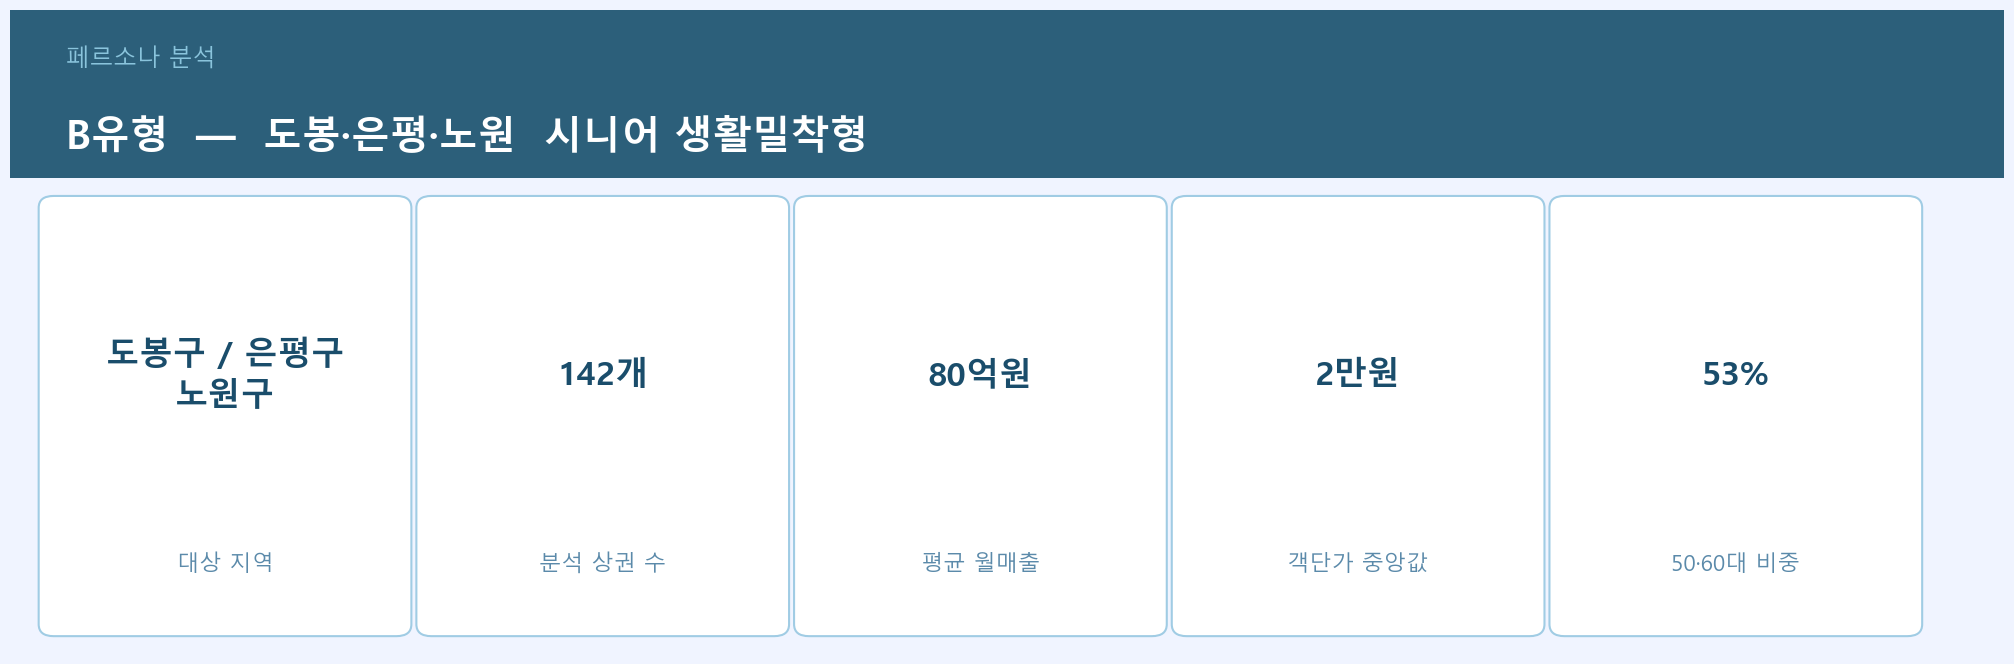

In [29]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

avg_sales   = g['총매출_억'].mean()
median_unit = g['객단가'].median()
senior_pct  = g['연령5060비중'].mean() * 100

attrs = [
    ('대상 지역',    '도봉구 / 은평구\n노원구'),
    ('분석 상권 수',  f'{len(g)}개'),
    ('평균 월매출',   f'{avg_sales:.0f}억원'),
    ('객단가 중앙값',  f'{median_unit/10000:.0f}만원'),
    ('50·60대 비중', f'{senior_pct:.0f}%'),
]

fig = plt.figure(figsize=(20, 6.5))
ax  = fig.add_subplot(111)
ax.set_xlim(0, 16)
ax.set_ylim(0, 6.5)
ax.axis('off')
fig.patch.set_facecolor('#f0f4ff')
ax.set_facecolor('#f0f4ff')

# 헤더 (짙은 청록 계열 — 시니어/생활밀착 느낌)
ax.add_patch(FancyBboxPatch((0, 4.8), 16, 1.7, boxstyle='square,pad=0',
                             facecolor='#2c5f7a', edgecolor='none'))
ax.text(0.45, 6.0, '페르소나 분석', fontsize=17, color='#8ac4dc', va='center', style='italic')
ax.text(0.45, 5.2, 'B유형  —  도봉·은평·노원  시니어 생활밀착형',
        fontsize=28, color='white', fontweight='bold', va='center')

box_w, gap, start_x = 2.75, 0.28, 0.35
for i, (label, value) in enumerate(attrs):
    x = start_x + i * (box_w + gap)
    ax.add_patch(FancyBboxPatch((x, 0.3), box_w, 4.2,
                                 boxstyle='round,pad=0.12',
                                 facecolor='white', edgecolor='#a0cce4', linewidth=1.5))
    ax.text(x + box_w / 2, 2.8, value,
            ha='center', va='center', fontsize=24, color='#1a4d6b',
            fontweight='bold', multialignment='center', linespacing=1.3)
    ax.text(x + box_w / 2, 0.9, label,
            ha='center', va='center', fontsize=16, color='#5b8aaa')

plt.tight_layout(pad=0.2)
plt.savefig('../data/output/B유형_페르소나카드.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 1. B유형 현황 — 도봉·은평·노원 상권은 지금 어디에 있는가

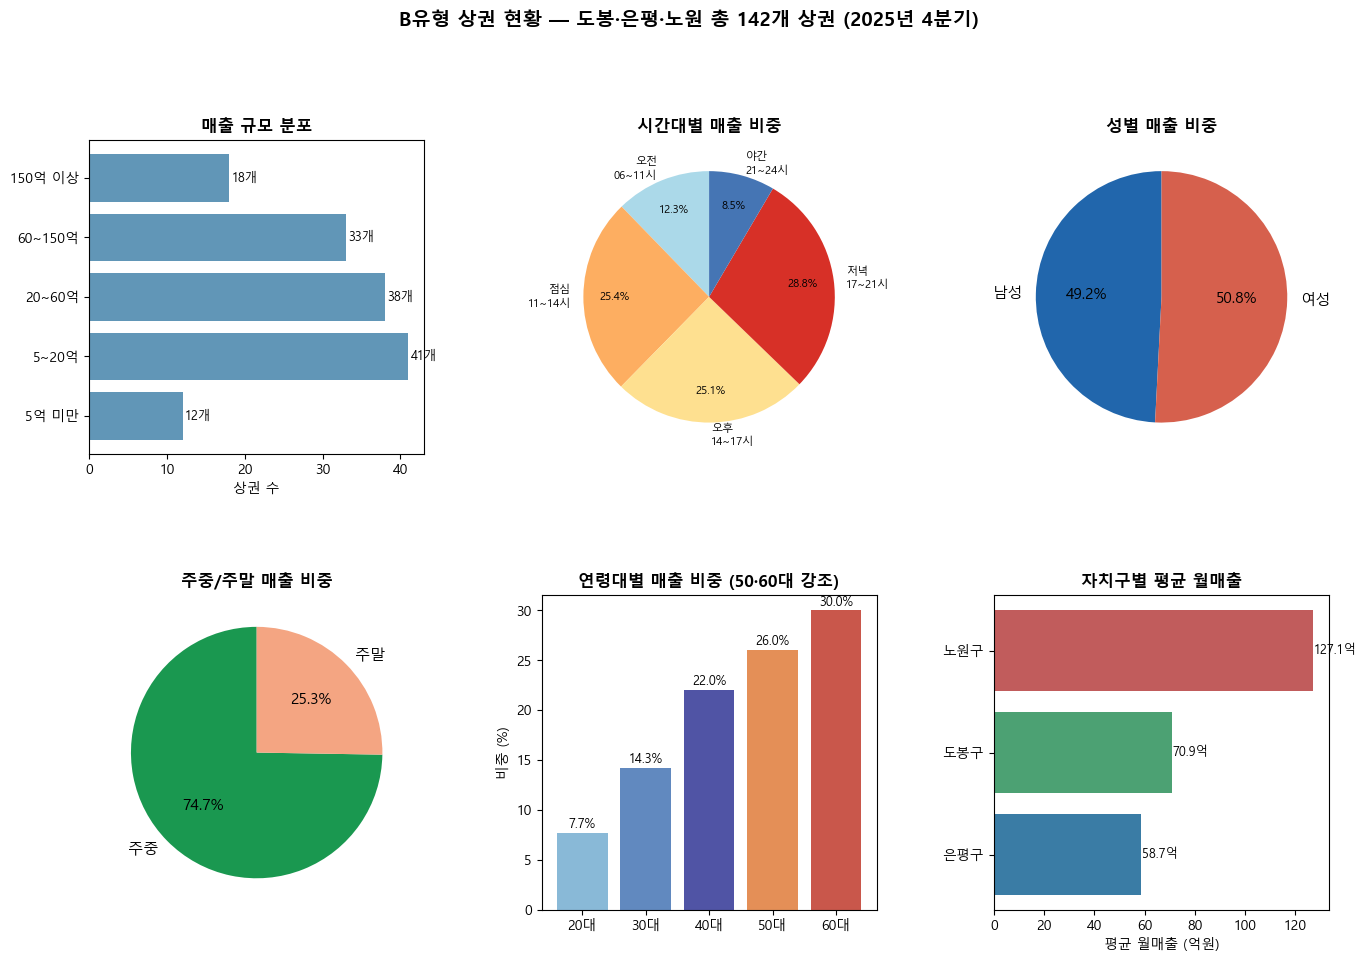

In [30]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── (1) 매출 규모 분포
ax1 = fig.add_subplot(gs[0, 0])
bins = [0, 5, 20, 60, 150, g['총매출_억'].max() + 1]
labels_bin = ['5억 미만', '5~20억', '20~60억', '60~150억', '150억 이상']
g['매출구간'] = pd.cut(g['총매출_억'], bins=bins, labels=labels_bin)
매출구간_cnt = g['매출구간'].value_counts().reindex(labels_bin)
bars = ax1.barh(labels_bin, 매출구간_cnt.values, color='#3a7ca5', alpha=0.8)
for bar, val in zip(bars, 매출구간_cnt.values):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val}개', va='center', fontsize=9)
ax1.set_xlabel('상권 수')
ax1.set_title('매출 규모 분포', fontweight='bold')

# ── (2) 시간대별 매출 비중 (전체 평균)
ax2 = fig.add_subplot(gs[0, 1])
time_cols = ['오전매출', '점심매출', '오후매출', '저녁매출', '야간매출']
time_labels = ['오전\n06~11시', '점심\n11~14시', '오후\n14~17시', '저녁\n17~21시', '야간\n21~24시']
time_vals = [g[c].sum() for c in time_cols]
time_pct = [v / sum(time_vals) * 100 for v in time_vals]
colors_t = ['#abd9e9', '#fdae61', '#fee090', '#d73027', '#4575b4']
wedges, texts, autotexts = ax2.pie(
    time_pct, labels=time_labels, autopct='%1.1f%%',
    colors=colors_t, startangle=90, pctdistance=0.75,
    textprops={'fontsize': 8}
)
for at in autotexts:
    at.set_fontsize(8)
ax2.set_title('시간대별 매출 비중', fontweight='bold')

# ── (3) 성별 매출 비중
ax3 = fig.add_subplot(gs[0, 2])
m_total = g['남성매출'].sum()
f_total = g['여성매출'].sum()
ax3.pie([m_total, f_total], labels=['남성', '여성'],
        autopct='%1.1f%%', colors=['#2166ac', '#d6604d'],
        startangle=90, textprops={'fontsize': 11})
ax3.set_title('성별 매출 비중', fontweight='bold')

# ── (4) 주중/주말 매출 비중
ax4 = fig.add_subplot(gs[1, 0])
wd = g['주중매출'].sum()
we = g['주말매출'].sum()
ax4.pie([wd, we], labels=['주중', '주말'],
        autopct='%1.1f%%', colors=['#1a9850', '#f4a582'],
        startangle=90, textprops={'fontsize': 11})
ax4.set_title('주중/주말 매출 비중', fontweight='bold')

# ── (5) 연령대별 매출 비중 (50·60대 강조)
ax5 = fig.add_subplot(gs[1, 1])
age_cols = ['연령20매출', '연령30매출', '연령40매출', '연령50매출', '연령60매출']
age_labels = ['20대', '30대', '40대', '50대', '60대']
age_vals = [g[c].sum() for c in age_cols]
colors_a = ['#74add1', '#4575b4', '#313695', '#e07b39', '#c0392b']
bars5 = ax5.bar(age_labels, [v/sum(age_vals)*100 for v in age_vals],
        color=colors_a, alpha=0.85)
for i, v in enumerate([v/sum(age_vals)*100 for v in age_vals]):
    ax5.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
ax5.set_ylabel('비중 (%)')
ax5.set_title('연령대별 매출 비중 (50·60대 강조)', fontweight='bold')

# ── (6) 자치구별 평균 월매출
ax6 = fig.add_subplot(gs[1, 2])
gu_매출 = g.groupby('자치구_코드_명')['총매출_억'].mean().sort_values(ascending=True)
ax6.barh(gu_매출.index, gu_매출.values, color=['#3a7ca5', '#4ca173', '#c15c5c'])
for i, v in enumerate(gu_매출.values):
    ax6.text(v + 0.1, i, f'{v:.1f}억', va='center', fontsize=9)
ax6.set_xlabel('평균 월매출 (억원)')
ax6.set_title('자치구별 평균 월매출', fontweight='bold')

fig.suptitle(f'B유형 상권 현황 — 도봉·은평·노원 총 {len(g)}개 상권 (2025년 4분기)',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('../data/output/B유형_현황.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. 상권 세분화 — 데이터가 말하는 4가지 유형

소비 패턴(시간대·성별·주말 비중·50·60대 비중)으로 K-Means 클러스터링을 수행한다.

In [31]:
FEAT_COLS = ['점심비중', '저녁비중', '야간비중', '주말비중', '여성비중', '연령5060비중']
g['log_객단가'] = np.log(g['객단가'])
FEAT_ALL = FEAT_COLS + ['log_객단가']

X_raw = g[FEAT_ALL].values
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

sil_scores = {}
for k in range(2, 7):
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    sil_scores[k] = silhouette_score(X, km_tmp.fit_predict(X))
best_k = max(sil_scores, key=sil_scores.get)
print(f'Silhouette scores: {sil_scores}')
print(f'최적 k = {best_k}')

K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
g['클러스터'] = km.fit_predict(X)

profile = g.groupby('클러스터')[FEAT_COLS + ['총매출_억', '객단가']].mean()
print('\n클러스터별 평균 프로파일:')
print(profile.round(3))

# 유형명 자동 할당
# · 야간비중 MAX      → 저녁·야간 활성형
# · 총매출 MAX        → 고매출 시니어 여성형
# · 점심비중 MAX(이상치) → 근린 기타형
# · 나머지             → 평일 전문 상가형
def assign_name(row):
    if row['야간비중'] == profile['야간비중'].max():
        return '① 저녁·야간 활성형'
    elif row['총매출_억'] == profile['총매출_억'].max():
        return '② 고매출 시니어 여성형'
    elif row['점심비중'] == profile['점심비중'].max():
        return '④ 근린 기타형'
    else:
        return '③ 평일 전문 상가형'

profile['유형명'] = profile.apply(assign_name, axis=1)

names_pool = ['① 저녁·야간 활성형', '② 고매출 시니어 여성형', '③ 평일 전문 상가형', '④ 근린 기타형']
seen = {}
for idx in profile.index:
    name = profile.loc[idx, '유형명']
    if name in seen:
        remaining = [n for n in names_pool if n not in set(profile['유형명'])]
        if remaining:
            profile.loc[idx, '유형명'] = remaining[0]
    seen[name] = idx

assigned = set(profile['유형명'])
for idx in profile.index:
    if profile.loc[idx, '유형명'] not in names_pool:
        remaining = [n for n in names_pool if n not in assigned]
        profile.loc[idx, '유형명'] = remaining[0] if remaining else f'유형{idx}'
        assigned.add(profile.loc[idx, '유형명'])

g['유형명'] = g['클러스터'].map(profile['유형명'])
유형_순서 = ['① 저녁·야간 활성형', '② 고매출 시니어 여성형', '③ 평일 전문 상가형', '④ 근린 기타형']

print('\n유형별 상권 수:')
print(g['유형명'].value_counts())

Silhouette scores: {2: 0.22693995294211128, 3: 0.20634579388820729, 4: 0.22786450763367747, 5: 0.2064627109425926, 6: 0.19151805468292654}
최적 k = 4

클러스터별 평균 프로파일:
       점심비중   저녁비중   야간비중   주말비중   여성비중  연령5060비중    총매출_억        객단가
클러스터                                                                 
0     0.190  0.358  0.137  0.289  0.410     0.494   43.706  26068.035
1     0.265  0.258  0.053  0.231  0.527     0.577  128.911  23138.747
2     0.277  0.275  0.068  0.196  0.335     0.490   51.684  43958.559
3     0.817  0.000  0.000  0.000  0.549     1.000    0.006  24782.000

유형별 상권 수:
유형명
① 저녁·야간 활성형      61
② 고매출 시니어 여성형    59
③ 평일 전문 상가형      21
④ 근린 기타형          1
Name: count, dtype: int64


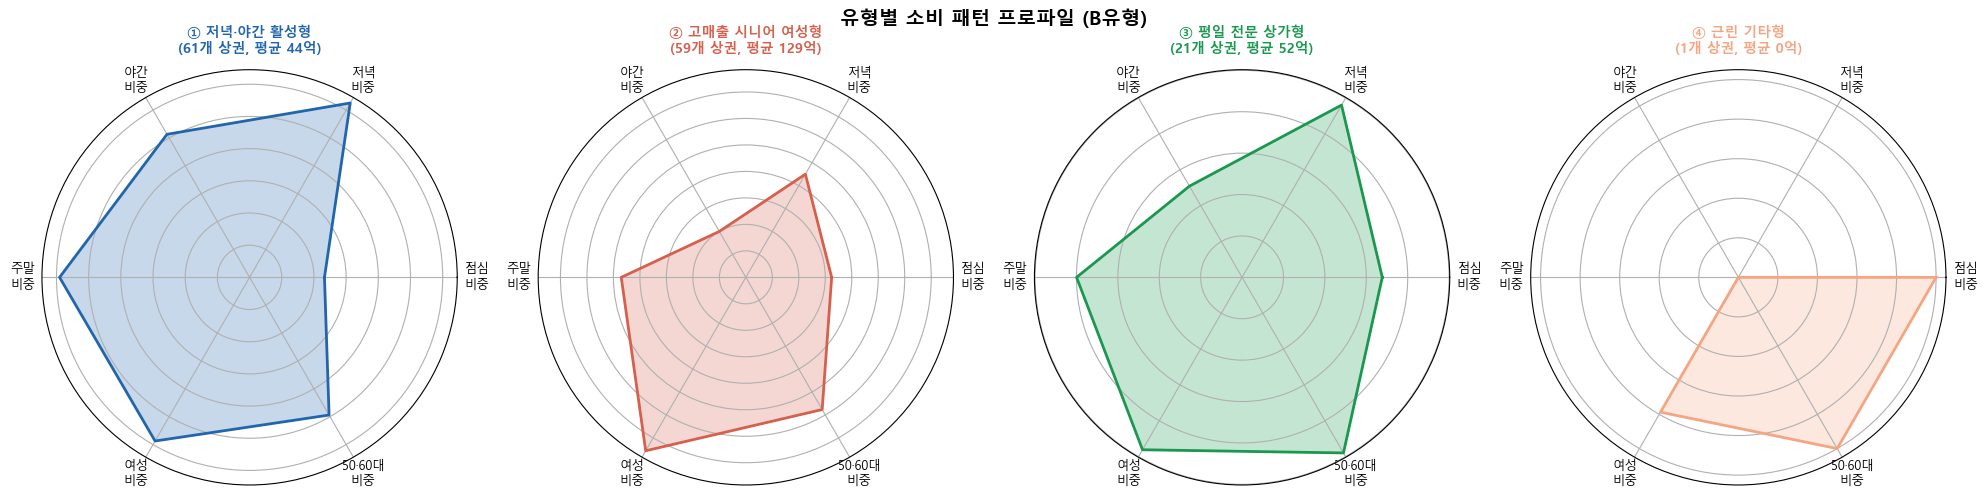

In [32]:
# ── 클러스터 프로파일 레이더 차트
color_map = {유형: OKR_COLORS[i] for i, 유형 in enumerate(유형_순서)}

radar_feats = ['점심비중', '저녁비중', '야간비중', '주말비중', '여성비중', '연령5060비중']
radar_labels = ['점심\n비중', '저녁\n비중', '야간\n비중', '주말\n비중', '여성\n비중', '50·60대\n비중']
N = len(radar_feats)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), subplot_kw=dict(polar=True))
fig.suptitle('유형별 소비 패턴 프로파일 (B유형)', fontsize=14, fontweight='bold')

유형_to_cluster = {v: k for k, v in profile['유형명'].items()}

for ax, 유형 in zip(axes, 유형_순서):
    cid = 유형_to_cluster.get(유형)
    if cid is None:
        continue
    subset = g[g['클러스터'] == cid]
    vals = [subset[f].mean() for f in radar_feats]
    global_max = [g[f].max() for f in radar_feats]
    vals_norm = [v / m if m > 0 else 0 for v, m in zip(vals, global_max)]
    vals_norm += vals_norm[:1]

    ax.plot(angles, vals_norm, color=color_map[유형], linewidth=2)
    ax.fill(angles, vals_norm, alpha=0.25, color=color_map[유형])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_yticklabels([])
    ax.set_title(
        f'{유형}\n({len(subset)}개 상권, 평균 {subset["총매출_억"].mean():.0f}억)',
        fontsize=10, fontweight='bold', color=color_map[유형], pad=12
    )

plt.tight_layout()
plt.savefig('../data/output/B유형_클러스터_레이더.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. 유형별 문제 진단 + 맞춤 전략 + 예상 매출 지표


  ① 저녁·야간 활성형  (61개 상권)
  [문제점] 야간 매출은 있으나 인건비 부담·어르신 야간 외출 포기율로 실매출 전환이 제한적.
    1. 동네 점포 야간 무인 운영(스마트슈퍼) 도입 (중기부 시범사업: 낮 유인·야간 무인 하이브리드형, 1호점 일 매출 +32.6% 입증 → 야간 인건비 절감·시니어 야간 구매 포기율 저하)
  현재 21.9억 → 목표 23.2억 (+5.9%), 연간효과 476억

  ② 고매출 시니어 여성형  (59개 상권)
  [문제점] 현재 고매출이지만 디지털 소외(시력 저하·키오스크 기피)·대형마트 이탈로 매출 기반 잠식 위험.
    1. 로컬 커머스 앱·키오스크 어르신 친화 큰 글씨 UI 전면 개편 (금융위·금감원 가이드라인 기준, 18개 은행 고령자모드 출시 완료 → 지역 상권 앱에 동일 표준 적용)
    2. 지역화폐 연계 시니어 단골 리워드 도입 (행안부 지역사랑상품권: 골목상권 전용 구조 + 월 3회 이상 방문 시 추가 캐시백 → 대형마트 이탈 방지·단골 락인)
  현재 59.8억 → 목표 65.3억 (+9.2%), 연간효과 1942억

  ③ 평일 전문 상가형  (21개 상권)
  [문제점] 높은 객단가에도 병원·약국 방문 이후 인근 상권 소비 연계 미흡. 진료 후 이동 부담으로 추가 소비 포기.
    1. 병의원 진료 동선 연계 시니어 헬스케어 마일리지 활용 (복지부·건보공단 건강생활실천지원금제: 연 최대 5~6만원 적립, 사용처 확장으로 동네 식당·카페 크로스셀링 유도)
    2. 진료 후 장보기 편의 위한 시니어 물류·식사 지원 연계 (복지부 지역사회 통합돌봄 인프라 응용 → 진료 후 짐 배달 서비스로 동네 상권 이탈 방지)
  현재 23.4억 → 목표 27.0억 (+15.0%), 연간효과 443억

  ④ 근린 기타형  (1개 상권)
  [문제점] 극소형 상권으로 디지털·물리적 접근성 모두 취약. 영세 점포가 자력으로 무인화·배리어프리 구축 불가.
    1. 배리어프리 무인 안내기(키오스크) 보조

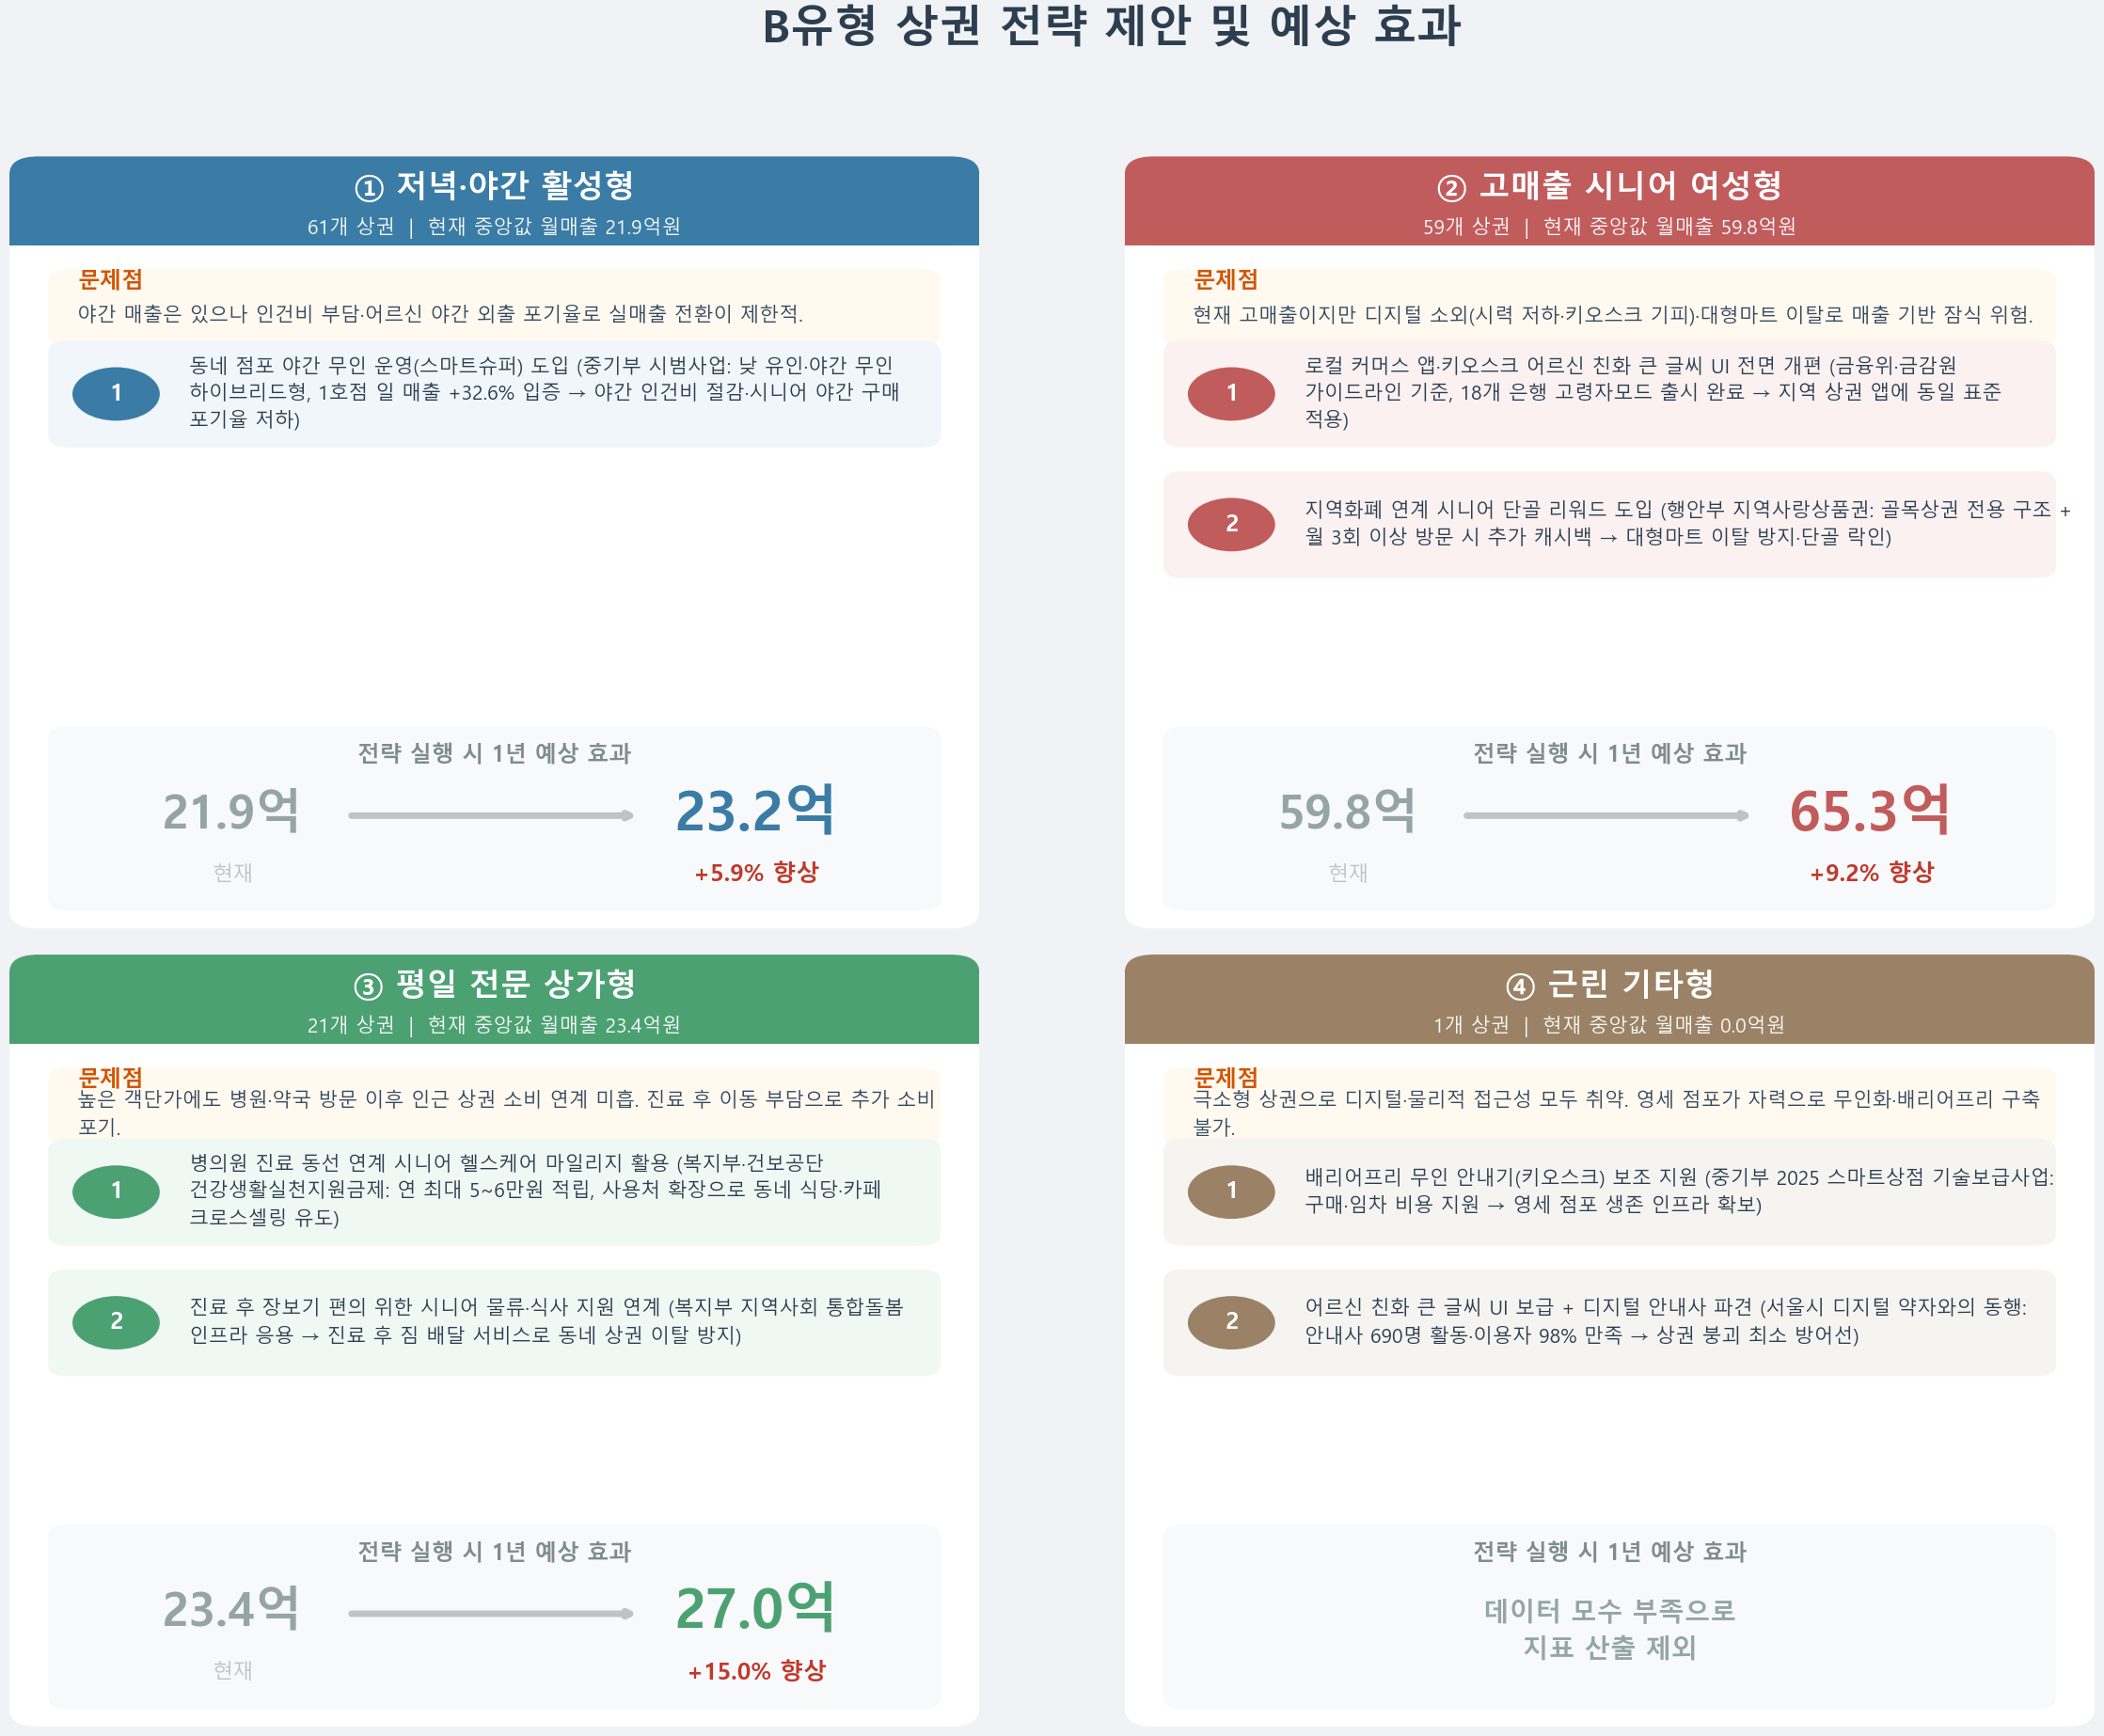

In [33]:
import textwrap, re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# ── 유형별 현재 → 목표 매출 계산 (동적 계산)
strategy_info = {
    '① 저녁·야간 활성형': {
        '문제': '야간 매출은 있으나 인건비 부담·어르신 야간 외출 포기율로 실매출 전환이 제한적.',
        '전략': [
            '1. 동네 점포 야간 무인 운영(스마트슈퍼) 도입 (중기부 시범사업: 낮 유인·야간 무인 하이브리드형, 1호점 일 매출 +32.6% 입증 → 야간 인건비 절감·시니어 야간 구매 포기율 저하)',
        ],
    },
    '② 고매출 시니어 여성형': {
        '문제': '현재 고매출이지만 디지털 소외(시력 저하·키오스크 기피)·대형마트 이탈로 매출 기반 잠식 위험.',
        '전략': [
            '1. 로컬 커머스 앱·키오스크 어르신 친화 큰 글씨 UI 전면 개편 (금융위·금감원 가이드라인 기준, 18개 은행 고령자모드 출시 완료 → 지역 상권 앱에 동일 표준 적용)',
            '2. 지역화폐 연계 시니어 단골 리워드 도입 (행안부 지역사랑상품권: 골목상권 전용 구조 + 월 3회 이상 방문 시 추가 캐시백 → 대형마트 이탈 방지·단골 락인)',
        ],
    },
    '③ 평일 전문 상가형': {
        '문제': '높은 객단가에도 병원·약국 방문 이후 인근 상권 소비 연계 미흡. 진료 후 이동 부담으로 추가 소비 포기.',
        '전략': [
            '1. 병의원 진료 동선 연계 시니어 헬스케어 마일리지 활용 (복지부·건보공단 건강생활실천지원금제: 연 최대 5~6만원 적립, 사용처 확장으로 동네 식당·카페 크로스셀링 유도)',
            '2. 진료 후 장보기 편의 위한 시니어 물류·식사 지원 연계 (복지부 지역사회 통합돌봄 인프라 응용 → 진료 후 짐 배달 서비스로 동네 상권 이탈 방지)',
        ],
    },
    '④ 근린 기타형': {
        '문제': '극소형 상권으로 디지털·물리적 접근성 모두 취약. 영세 점포가 자력으로 무인화·배리어프리 구축 불가.',
        '전략': [
            '1. 배리어프리 무인 안내기(키오스크) 보조 지원 (중기부 2025 스마트상점 기술보급사업: 구매·임차 비용 지원 → 영세 점포 생존 인프라 확보)',
            '2. 어르신 친화 큰 글씨 UI 보급 + 디지털 안내사 파견 (서울시 디지털 약자와의 동행: 안내사 690명 활동·이용자 98% 만족 → 상권 붕괴 최소 방어선)',
        ],
    },
}

results = {}
for 유형 in 유형_순서:
    cid = 유형_to_cluster.get(유형)
    if cid is None:
        continue
    subset = g[g['클러스터'] == cid]
    현재 = subset['총매출_억'].median()
    상권수 = len(subset)
    현실적_벤치마크 = subset['총매출_억'].quantile(0.60)
    갭 = max(현실적_벤치마크 - 현재, 0)
    최종_목표 = min(현재 + 갭 * 0.15, 현재 * 1.15)
    개선율 = (최종_목표 - 현재) / 현재 * 100 if 현재 > 0 else 0
    연간효과_억 = (최종_목표 - 현재) * 6 * 상권수
    results[유형] = {
        '상권수': 상권수, '현재_억': 현재, '벤치마크_억': 현실적_벤치마크,
        '목표_억': 최종_목표, '개선율_%': 개선율, '연간효과_억': 연간효과_억,
    }
    info = strategy_info.get(유형, {})
    print(f'\n{"="*60}')
    print(f'  {유형}  ({상권수}개 상권)')
    print(f'  [문제점] {info.get("문제", "-")}')
    for s in info.get('전략', []):
        print(f'    {s}')
    print(f'  현재 {현재:.1f}억 → 목표 {최종_목표:.1f}억 (+{개선율:.1f}%), 연간효과 {연간효과_억:.0f}억')

# ── 전략 카드 시각화
유형_순서_v = ['① 저녁·야간 활성형', '② 고매출 시니어 여성형', '③ 평일 전문 상가형', '④ 근린 기타형']
CARD_COLORS = {
    '① 저녁·야간 활성형':   '#3A7CA5',
    '② 고매출 시니어 여성형': '#C15C5C',
    '③ 평일 전문 상가형':    '#4CA173',
    '④ 근린 기타형':        '#9B8266',
}
LIGHT_COLORS = {
    '① 저녁·야간 활성형':   '#F0F6FA',
    '② 고매출 시니어 여성형': '#FBF1F1',
    '③ 평일 전문 상가형':    '#F0F8F3',
    '④ 근린 기타형':        '#F6F4F1',
}

fig, axes = plt.subplots(2, 2, figsize=(24, 18))
fig.patch.set_facecolor('#F0F2F5')
fig.suptitle('B유형 상권 전략 제안 및 예상 효과', fontsize=34, fontweight='bold', y=1.03, color='#2C3E50')

for ax, 유형 in zip(axes.flat, 유형_순서_v):
    color  = CARD_COLORS[유형]
    lcolor = LIGHT_COLORS[유형]
    r      = results.get(유형, {})
    info   = strategy_info.get(유형, {})

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 13)
    ax.axis('off')
    ax.add_patch(FancyBboxPatch((0, 0), 10, 13, boxstyle='round,pad=0,rounding_size=0.3',
                                 facecolor='white', edgecolor='none', zorder=0))

    # 헤더
    ax.add_patch(FancyBboxPatch((0, 11.5), 10, 1.5, boxstyle='round,pad=0,rounding_size=0.3',
                                 facecolor=color, edgecolor='none'))
    ax.add_patch(plt.Rectangle((0, 11.5), 10, 0.5, facecolor=color, edgecolor='none'))
    ax.text(5, 12.45, 유형, ha='center', va='center', fontsize=24, color='white', fontweight='bold')
    ax.text(5, 11.8,
            f'{r.get("상권수",0)}개 상권  |  현재 중앙값 월매출 {r.get("현재_억",0):.1f}억원',
            ha='center', va='center', fontsize=15, color='white', alpha=0.95)

    # 문제점
    ax.add_patch(FancyBboxPatch((0.4, 9.8), 9.2, 1.3, boxstyle='round,pad=0,rounding_size=0.2',
                                 facecolor='#FFF9F0', edgecolor='none'))
    ax.text(0.7, 10.8, '문제점', fontsize=17, color='#D35400', fontweight='bold')
    prob_w = textwrap.fill(info.get('문제', ''), width=55)
    ax.text(0.7, 10.3, prob_w, fontsize=15, color='#34495E', va='center', linespacing=1.5)

    # 전략 박스
    strats = info.get('전략', [])
    strat_y_fixed = [8.1, 5.9, 3.7]
    for j, (s, top) in enumerate(zip(strats[:3], strat_y_fixed)):
        ax.add_patch(FancyBboxPatch((0.4, top), 9.2, 1.8, boxstyle='round,pad=0,rounding_size=0.2',
                                     facecolor=lcolor, edgecolor='none'))
        cy = top + 0.9
        ax.add_patch(mpatches.Circle((1.1, cy), 0.45, facecolor=color, edgecolor='none', zorder=3))
        ax.text(1.1, cy, str(j + 1), ha='center', va='center',
                fontsize=18, color='white', fontweight='bold', zorder=4)
        s_clean = re.sub(r'^\d+\.\s*', '', s)
        s_wrap  = textwrap.fill(s_clean, width=48)
        ax.text(1.85, cy, s_wrap, fontsize=15, color='#2C3E50', va='center', linespacing=1.45)

    # 예상 지표
    ax.add_patch(FancyBboxPatch((0.4, 0.3), 9.2, 3.1, boxstyle='round,pad=0,rounding_size=0.2',
                                 facecolor='#F8F9FA', edgecolor='none'))
    ax.text(5, 3.1, '전략 실행 시 1년 예상 효과',
            ha='center', va='top', fontsize=17, color='#7F8C8D', fontweight='bold')

    현재_v = r.get('현재_억', 0)
    목표_v  = r.get('목표_억', 0)
    개선율_v = r.get('개선율_%', 0)
    if r.get('상권수', 0) <= 1 or 현재_v == 0:
        ax.text(5, 1.6, '데이터 모수 부족으로\n지표 산출 제외',
                ha='center', va='center', fontsize=20, color='#95A5A6',
                fontweight='bold', linespacing=1.5)
    else:
        ax.text(2.3, 1.9, f'{현재_v:.1f}억',
                ha='center', va='center', fontsize=36, color='#95A5A6', fontweight='bold')
        ax.text(2.3, 0.9, '현재', ha='center', va='center', fontsize=16, color='#BDC3C7')
        ax.annotate('', xy=(6.5, 1.9), xytext=(3.5, 1.9),
                    arrowprops=dict(arrowstyle='->', color='#BDC3C7', lw=5.0))
        ax.text(7.7, 1.9, f'{목표_v:.1f}억',
                ha='center', va='center', fontsize=42, color=color, fontweight='bold')
        ax.text(7.7, 0.9, f'+{개선율_v:.1f}% 향상',
                ha='center', va='center', fontsize=18, color='#C0392B', fontweight='bold')

plt.tight_layout(pad=2.0)
plt.savefig('../data/output/B유형_전략카드.png', dpi=300, bbox_inches='tight')
plt.show()

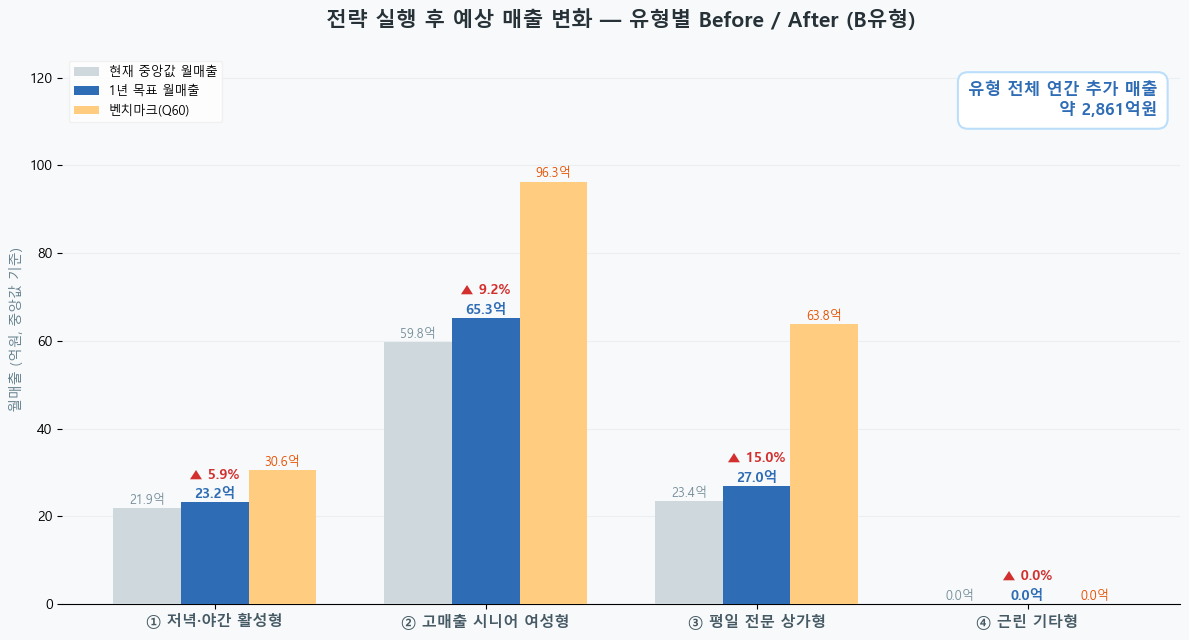

연간 추가 매출 유발 효과: 약 2,861억원


In [34]:
# ── Before / After 매출 비교 차트 (results는 앞 셀에서 계산됨)
유형_labels  = list(results.keys())
현재_vals    = [results[u]['현재_억']    for u in 유형_labels]
목표_vals    = [results[u]['목표_억']    for u in 유형_labels]
벤치마크_vals = [results[u]['벤치마크_억'] for u in 유형_labels]

fig, ax = plt.subplots(figsize=(12, 6.5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

x     = np.arange(len(유형_labels))
width = 0.25

bars_현재 = ax.bar(x - width, 현재_vals,    width, label='현재 중앙값 월매출', color='#CFD8DC', edgecolor='none', zorder=3)
bars_목표  = ax.bar(x,         목표_vals,    width, label='1년 목표 월매출',    color='#2E6CB5', edgecolor='none', zorder=3)
bars_bench = ax.bar(x + width, 벤치마크_vals, width, label='벤치마크(Q60)',     color='#FFCC80', edgecolor='none', zorder=3)

for bar in bars_현재:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, f'{h:.1f}억',
                ha='center', va='bottom', fontsize=9, color='#78909C')

for i, bar in enumerate(bars_목표):
    h = bar.get_height()
    개선율 = results[유형_labels[i]]['개선율_%']
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, f'{h:.1f}억',
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2E6CB5')
        ax.text(bar.get_x() + bar.get_width() / 2, h + max(벤치마크_vals) * 0.05,
                f'▲ {개선율:.1f}%', ha='center', va='bottom', fontsize=10,
                fontweight='bold', color='#D32F2F')

for bar in bars_bench:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, f'{h:.1f}억',
                ha='center', va='bottom', fontsize=9, color='#E65100')

# ④ 근린 기타형 예외 안내
if results.get('④ 근린 기타형', {}).get('현재_억', 0) == 0:
    ax.text(3, max(벤치마크_vals) * 0.05, '데이터 모수 부족\n지표 산출 제외',
            ha='center', va='bottom', fontsize=9, color='#95A5A6')

ax.set_xticks(x)
ax.set_xticklabels(유형_labels, fontsize=11, fontweight='bold', color='#455A64')
ax.set_ylabel('월매출 (억원, 중앙값 기준)', fontsize=10, color='#607D8B')
ax.set_title('전략 실행 후 예상 매출 변화 — 유형별 Before / After (B유형)',
             fontsize=15, fontweight='bold', pad=20, color='#263238')
ax.grid(axis='y', linestyle='-', color='#ECEFF1', zorder=0)
sns.despine(left=True, bottom=False)
ax.legend(fontsize=9, loc='upper left', frameon=True, edgecolor='#EEEEEE', facecolor='white')
ax.set_ylim(0, max(벤치마크_vals) * 1.3)

total_연간 = sum(results[u]['연간효과_억'] for u in 유형_labels)
ax.text(0.98, 0.95,
        f'유형 전체 연간 추가 매출\n약 {total_연간:,.0f}억원',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=12, fontweight='bold', color='#2E6CB5',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='#BBDEFB', linewidth=1.5))

plt.tight_layout()
plt.savefig('../data/output/B유형_전략_BeforeAfter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'연간 추가 매출 유발 효과: 약 {total_연간:,.0f}억원')

---
## 4. 지도 시각화 — 유형별 상권 분포

In [35]:
# ── 유형별 색상 Folium 지도
color_map_folium = {
    '① 저녁·야간 활성형':   '#2166ac',
    '② 고매출 시니어 여성형': '#d6604d',
    '③ 평일 전문 상가형':    '#1a9850',
    '④ 근린 기타형':        '#f4a582',
}

center_lat = g['lat'].mean()
center_lon = g['lon'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles='CartoDB positron'
)
MiniMap(toggle_display=True).add_to(m)

for 유형 in 유형_순서:
    subset = g[g['유형명'] == 유형].dropna(subset=['lat', 'lon'])
    color = color_map_folium.get(유형, '#888888')
    fg = folium.FeatureGroup(name=f'{유형} ({len(subset)}개)', show=True)

    for _, row in subset.iterrows():
        radius = max(4, min(18, row['총매출_억'] ** 0.4))
        popup_html = (
            f"<b>{row['상권_코드_명']}</b><br>"
            f"유형: {유형}<br>"
            f"월매출: {row['총매출_억']:.1f}억원<br>"
            f"객단가: {row['객단가']:,.0f}원<br>"
            f"자치구: {row['자치구_코드_명']}"
        )
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.65,
            weight=1.2,
            popup=folium.Popup(popup_html, max_width=200),
            tooltip=row['상권_코드_명'],
        ).add_to(fg)
    fg.add_to(m)

legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:9999;
     background:#fff; padding:12px 16px; border-radius:8px;
     border:1px solid #ccc; font-size:13px; line-height:1.8;">
  <b>B유형 상권 유형</b><br>
  <span style="color:#2166ac;">&#9679;</span> ① 저녁·야간 활성형<br>
  <span style="color:#d6604d;">&#9679;</span> ② 고매출 시니어 여성형<br>
  <span style="color:#1a9850;">&#9679;</span> ③ 평일 전문 상가형<br>
  <span style="color:#f4a582;">&#9679;</span> ④ 근린 기타형<br>
  <small style="color:#888;">원 크기 ∝ 월매출 규모</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl(collapsed=False).add_to(m)

out_path = '../data/output/B유형_클러스터_지도.html'
m.save(out_path)
print(f'저장 완료: {out_path}')
m

저장 완료: ../data/output/B유형_클러스터_지도.html
